# Shared-Ride Vehicle Tour Reconstruction — ADA Paratransit

## Key distinction from simple trajectory reconstruction

ADA paratransit is a **shared demand-responsive service**. Multiple riders can be in the vehicle simultaneously. The vehicle tour for one day looks like:

```
DEPOT → PICKUP(A) → PICKUP(B) → DROPOFF(A) → PICKUP(C) → DROPOFF(C) → DROPOFF(B) → DEPOT
```

The correct atomic unit is a **tour segment** — the stretch of road between any two consecutive events (any pickup or dropoff), with:
- Who is on board (occupancy set)
- How many passengers (load factor)
- Start/end location and time

## Event-stream approach

For each vehicle-day:
1. Collect **all pickup events** (from scheduled pickup times + locations)
2. Collect **all dropoff events** (from estimated/requested dropoff times + locations)
3. Sort the full event stream by time
4. Walk the stream: maintain occupancy set, emit one segment per consecutive event pair
5. Each segment carries the full passenger manifest for that stretch

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import warnings
from math import radians, sin, cos, sqrt, atan2
from datetime import timedelta
import folium
from folium import plugins
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
warnings.filterwarnings('ignore')

# ── Haversine distance ───────────────────────────────────────────
def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3958.8
    φ1, φ2 = radians(lat1), radians(lat2)
    Δφ, Δλ = radians(lat2-lat1), radians(lon2-lon1)
    a = sin(Δφ/2)**2 + cos(φ1)*cos(φ2)*sin(Δλ/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# ── Configuration ────────────────────────────────────────────────
AVG_SPEED_MPH     = 18     # urban driving speed estimate
LOADING_MIN       = 4      # minutes vehicle dwells at pickup
UNLOADING_MIN     = 3      # minutes vehicle dwells at dropoff
MIN_SEG_DIST_MI   = 0.05   # filter sub-50m noise segments
MAX_VEH_CAPACITY  = 8      # max wheelchair-accessible vehicle capacity

# Occupancy → colour (for map segments)
OCC_COLORS = {
    0: '#D3D1C7',   # empty / deadhead
    1: '#9FE1CB',
    2: '#1D9E75',
    3: '#EF9F27',
    4: '#D85A30',
    5: '#E24B4A',
}
def occ_color(n):
    return OCC_COLORS.get(min(n, 5), '#A32D2D')

print('✓ Setup complete')

✓ Setup complete


## 1. Load Data

In [3]:
# ── Replace with your path ───────────────────────────────────────
df = pd.read_csv('/Users/shives/Downloads/DOE_RFI/RFI-Rider_flexibility_index-/bjcta_para.csv')

# Auto-detect completed label
COMPLETED = df['Trip Status'].value_counts().index[0]
print(f'Completed label: {repr(COMPLETED)}')
print(f'Total trips    : {len(df):,}')
print(f'Vehicles       : {df["Run ID"].nunique()}')

Completed label: 'comp'
Total trips    : 165,891
Vehicles       : 61


## 2. Parse Times & Build Event Stream

In [4]:
def parse_mins(v):
    """Any time string → minutes since midnight."""
    if pd.isna(v) or str(v).strip() in ('','nan'): return np.nan
    s = str(v).strip()
    if ' ' in s:
        try:
            dt = pd.to_datetime(s)
            return dt.hour*60 + dt.minute
        except: return np.nan
    try:
        p = s.split(':')
        return int(p[0])*60 + int(p[1])
    except: return np.nan

# Parse trip date
df['trip_date'] = pd.to_datetime(
    df['Trip Date'].fillna(
        pd.to_datetime(df['Scheduled Pick-up Arrival Time'], errors='coerce').dt.normalize()
    ), errors='coerce'
)

# Parse all time columns
df['pu_sched_min'] = df['Scheduled Pick-up Arrival Time'].apply(parse_mins)
df['pu_early_min'] = df['Earliest Pick-up'].apply(parse_mins)
df['do_req_min']   = df['Requested Drop-off Time'].apply(parse_mins)
df['do_late_min']  = df['Latest Drop-off Time'].apply(parse_mins)

# Best pickup time: scheduled > earliest
df['pu_min'] = df['pu_sched_min'].fillna(df['pu_early_min'])

# Best dropoff time: requested > estimated from distance
def dist_row(r):
    try: return haversine_miles(r.pickup_lat, r.pickup_lon, r.dropoff_lat, r.dropoff_lon)
    except: return np.nan

df['dist_mi']      = df.apply(dist_row, axis=1)
df['est_drive_min']= (df['dist_mi'] / AVG_SPEED_MPH * 60).clip(lower=2)
df['do_est_min']   = df['pu_min'] + df['est_drive_min'] + LOADING_MIN

# Use requested dropoff if available, else estimated
df['do_min'] = df['do_req_min'].fillna(df['do_est_min'])

# ── Full Timestamp objects ────────────────────────────────────────
def mins_to_ts(date, mins):
    if pd.isna(date) or pd.isna(mins): return pd.NaT
    return date + timedelta(minutes=float(mins))

df['pickup_ts']  = [mins_to_ts(d, m) for d, m in zip(df['trip_date'], df['pu_min'])]
df['dropoff_ts'] = [mins_to_ts(d, m) for d, m in zip(df['trip_date'], df['do_min'])]

# ── Filter to valid completed trips ──────────────────────────────
valid = df[
    (df['Trip Status'] == COMPLETED) &
    df['Run ID'].notna() &
    df['pickup_ts'].notna() &
    df['dropoff_ts'].notna() &
    df['pickup_lat'].notna() & df['pickup_lon'].notna() &
    df['dropoff_lat'].notna() & df['dropoff_lon'].notna() &
    (df['dist_mi'] > MIN_SEG_DIST_MI)
].copy()

print(f'Valid trips: {len(valid):,}  across  {valid["Run ID"].nunique()} vehicles')

# ── Build the event stream ────────────────────────────────────────
# Each trip contributes TWO events: a PICKUP and a DROPOFF
pu_events = valid[[
    'Trip ID','Customer Number','Run ID','trip_date','Purpose',
    'pickup_ts','pickup_lat','pickup_lon',
    'dropoff_ts','dropoff_lat','dropoff_lon',
    'dist_mi','est_drive_min'
]].copy()
pu_events['event_type'] = 'PICKUP'
pu_events['event_ts']   = pu_events['pickup_ts']
pu_events['event_lat']  = pu_events['pickup_lat']
pu_events['event_lon']  = pu_events['pickup_lon']

do_events = valid[[
    'Trip ID','Customer Number','Run ID','trip_date','Purpose',
    'pickup_ts','pickup_lat','pickup_lon',
    'dropoff_ts','dropoff_lat','dropoff_lon',
    'dist_mi','est_drive_min'
]].copy()
do_events['event_type'] = 'DROPOFF'
do_events['event_ts']   = do_events['dropoff_ts']
do_events['event_lat']  = do_events['dropoff_lat']
do_events['event_lon']  = do_events['dropoff_lon']

events = pd.concat([pu_events, do_events], ignore_index=True)
events = events.sort_values(['Run ID','trip_date','event_ts']).reset_index(drop=True)

print(f'Total events in stream: {len(events):,}  (pickups + dropoffs)')
print('\nSample event stream for first vehicle-day:')
sample_veh = events['Run ID'].iloc[0]
sample_day = events['trip_date'].iloc[0]
display(
    events[(events['Run ID']==sample_veh) & (events['trip_date']==sample_day)]
    [['event_type','event_ts','Customer Number','Purpose','event_lat','event_lon']]
    .to_string()
)

Valid trips: 91,405  across  61 vehicles
Total events in stream: 182,810  (pickups + dropoffs)

Sample event stream for first vehicle-day:


'   event_type                   event_ts Customer Number   Purpose  event_lat  event_lon\n0      PICKUP 2022-06-01 04:25:00.000000            3523  Dialysis  33.463179 -86.834839\n1      PICKUP 2022-06-01 04:33:00.000000            9214  Dialysis  33.558062 -86.800404\n2     DROPOFF 2022-06-01 04:42:39.096451            9214  Dialysis  33.550790 -86.828527\n3     DROPOFF 2022-06-01 04:44:41.461603            3523  Dialysis  33.517799 -86.786011\n4      PICKUP 2022-06-01 05:00:00.000000            5277  Dialysis  33.537154 -86.888466\n5      PICKUP 2022-06-01 05:00:00.000000            2701      Work  33.548796 -86.827797\n6      PICKUP 2022-06-01 05:12:00.000000            4825  Dialysis  33.504619 -86.894894\n7     DROPOFF 2022-06-01 05:18:15.276618            5277  Dialysis  33.552395 -86.816493\n8      PICKUP 2022-06-01 05:30:00.000000            2907  Dialysis  33.499196 -86.884719\n9     DROPOFF 2022-06-01 05:31:37.157226            2701      Work  33.429925 -86.846781\n10    DRO

## 3. Reconstruct Tour Segments with Occupancy

Walk the event stream per vehicle-day. Between every consecutive pair of events, record:
- Which passengers are currently on board (occupancy set)
- The segment geometry and timing
- Whether it is a loaded segment or a deadhead

In [5]:
def reconstruct_tour(vehicle_day_events):
    """
    Walk the event stream for ONE vehicle-day.
    Returns list of segment dicts with full occupancy information.
    """
    evts = vehicle_day_events.sort_values('event_ts').reset_index(drop=True)
    if len(evts) < 2:
        return []

    on_board   = {}          # trip_id → rider info dict
    segments   = []

    for i in range(len(evts) - 1):
        curr = evts.iloc[i]
        nxt  = evts.iloc[i + 1]

        # ── Update occupancy based on current event ──────────────
        tid = str(curr['Trip ID'])
        if curr['event_type'] == 'PICKUP':
            on_board[tid] = {
                'customer': str(curr['Customer Number']),
                'purpose':  str(curr.get('Purpose', '')),
                'dest_lat': curr['dropoff_lat'],
                'dest_lon': curr['dropoff_lon'],
                'dest_ts':  curr['dropoff_ts'],
            }
        elif curr['event_type'] == 'DROPOFF':
            on_board.pop(tid, None)

        # ── Segment: from current event location → next event ────
        seg_dist = haversine_miles(
            curr['event_lat'], curr['event_lon'],
            nxt['event_lat'],  nxt['event_lon']
        )

        # Skip noise micro-segments (same stop)
        if seg_dist < MIN_SEG_DIST_MI and len(on_board) > 0:
            continue

        t_start  = curr['event_ts']
        t_end    = nxt['event_ts']
        duration = (t_end - t_start).total_seconds() / 60 if pd.notna(t_start) and pd.notna(t_end) else np.nan

        occ      = len(on_board)
        seg_type = 'loaded' if occ > 0 else 'deadhead'

        # Boarding and alighting at the NEXT event
        if nxt['event_type'] == 'PICKUP':
            next_action = f"PICKUP {nxt['Customer Number']}"
        else:
            next_action = f"DROPOFF {nxt['Customer Number']}"

        segments.append({
            # Identification
            'vehicle':          str(curr['Run ID']),
            'trip_date':        curr['trip_date'],
            'seg_index':        i,

            # Geometry
            'start_lat':        round(curr['event_lat'], 6),
            'start_lon':        round(curr['event_lon'], 6),
            'end_lat':          round(nxt['event_lat'], 6),
            'end_lon':          round(nxt['event_lon'], 6),

            # Timing
            'seg_start_ts':     t_start,
            'seg_end_ts':       t_end,
            'seg_start_time':   t_start.strftime('%H:%M:%S') if pd.notna(t_start) else '',
            'seg_end_time':     t_end.strftime('%H:%M:%S')   if pd.notna(t_end)   else '',
            'duration_min':     round(duration, 2)           if not np.isnan(duration) else np.nan,
            'distance_mi':      round(seg_dist, 4),

            # Triggering event
            'event_at_start':   curr['event_type'],
            'rider_at_start':   str(curr['Customer Number']),
            'next_action':      next_action,

            # Occupancy
            'occupancy':        occ,
            'seg_type':         seg_type,
            'load_factor':      round(occ / MAX_VEH_CAPACITY, 3),

            # Passenger manifest (who is on board during this segment)
            'passengers_on_board': '|'.join(v['customer'] for v in on_board.values()),
            'purposes_on_board':   '|'.join(v['purpose']  for v in on_board.values()),
            'trip_ids_on_board':   '|'.join(on_board.keys()),
            'n_purposes_on_board': len(set(v['purpose'] for v in on_board.values())),
        })

    return segments

# ── Apply to all vehicle-days ─────────────────────────────────────
all_segments = []
group_keys   = events.groupby(['Run ID','trip_date'])

for (vehicle, date), grp in group_keys:
    segs = reconstruct_tour(grp)
    all_segments.extend(segs)

segs_df = pd.DataFrame(all_segments)

print(f'Total tour segments reconstructed : {len(segs_df):,}')
print(f'  Loaded segments   : {(segs_df["seg_type"]=="loaded").sum():,}')
print(f'  Deadhead segments : {(segs_df["seg_type"]=="deadhead").sum():,}')
print(f'\nOccupancy distribution:')
print(segs_df['occupancy'].value_counts().sort_index().to_string())

print('\nSample segments with occupancy:')
display(
    segs_df[segs_df['occupancy']>0][
        ['vehicle','seg_start_time','seg_end_time','occupancy',
         'distance_mi','passengers_on_board','purposes_on_board']
    ].head(8)
)

Total tour segments reconstructed : 153,449
  Loaded segments   : 121,822
  Deadhead segments : 31,627

Occupancy distribution:
0     31627
1     59237
2     33393
3     14431
4      6603
5      3663
6      2158
7      1217
8       687
9       277
10       78
11       34
12       20
13       13
14        6
15        2
16        1
17        1
18        1

Sample segments with occupancy:


,vehicle,seg_start_time,seg_end_time,occupancy,distance_mi,passengers_on_board,purposes_on_board
0,101,04:25:00,04:33:00,1,6.8494,3523,Dialysis
1,101,04:33:00,04:42:39,2,1.6955,3523|9214,Dialysis|Dialysis
2,101,04:42:39,04:44:41,1,3.3454,3523,Dialysis
4,101,05:00:00,05:00:00,1,3.5852,5277,Dialysis
5,101,05:00:00,05:12:00,2,4.9247,5277|2701,Dialysis|Work
6,101,05:12:00,05:18:15,3,5.5936,5277|2701|4825,Dialysis|Work|Dialysis
7,101,05:18:15,05:30:00,2,5.3809,2701|4825,Work|Dialysis
8,101,05:30:00,05:31:37,3,5.2621,2701|4825|2907,Work|Dialysis|Dialysis


## 4. Save Trajectory & Tour CSV

In [6]:
# ── GPS-tracker format CSV (one row per segment) ──────────────────
gps_export = segs_df[[
    'trip_date', 'vehicle',
    'seg_start_time', 'seg_end_time',
    'start_lat', 'start_lon', 'end_lat', 'end_lon',
    'distance_mi', 'duration_min',
    'seg_type', 'occupancy', 'load_factor',
    'passengers_on_board', 'purposes_on_board', 'trip_ids_on_board',
    'event_at_start', 'rider_at_start', 'next_action',
]].rename(columns={
    'trip_date':       'Date/Time',
    'vehicle':         'Vehicle',
    'seg_start_time':  'Depart',
    'seg_end_time':    'Arrive',
    'start_lat':       'StartLatitude',
    'start_lon':       'StartLongitude',
    'end_lat':         'StopLatitude',
    'end_lon':         'StopLongitude',
    'distance_mi':     'Distance Travelled',
    'duration_min':    'Drive Time',
    'seg_type':        'Segment Type',
    'occupancy':       'Occupancy',
    'load_factor':     'Load Factor',
})
gps_export.to_csv('vehicle_tour_segments.csv', index=False)
print(f'✓ Saved: vehicle_tour_segments.csv  ({len(gps_export):,} rows)')

# ── Vehicle-day summary ───────────────────────────────────────────
vday = segs_df.groupby(['vehicle','trip_date']).agg(
    n_segments       = ('seg_index',    'count'),
    loaded_segs      = ('seg_type',     lambda x: (x=='loaded').sum()),
    deadhead_segs    = ('seg_type',     lambda x: (x=='deadhead').sum()),
    total_dist_mi    = ('distance_mi',  'sum'),
    loaded_dist_mi   = ('distance_mi',  lambda x: x[segs_df.loc[x.index,'seg_type']=='loaded'].sum()),
    max_occupancy    = ('occupancy',    'max'),
    mean_occupancy   = ('occupancy',    'mean'),
    mean_load_factor = ('load_factor',  'mean'),
    service_start    = ('seg_start_ts', 'min'),
    service_end      = ('seg_end_ts',   'max'),
).reset_index()
vday['service_hours'] = (
    (vday['service_end'] - vday['service_start']).dt.total_seconds() / 3600
).clip(lower=0)
vday['deadhead_pct'] = (
    (vday['total_dist_mi'] - vday['loaded_dist_mi']) /
    vday['total_dist_mi'].replace(0, np.nan) * 100
).fillna(0)

vday.to_csv('vehicle_daily_summary.csv', index=False)
print(f'✓ Saved: vehicle_daily_summary.csv  ({len(vday):,} vehicle-days)')

print('\n── Fleet averages per vehicle-day ──────────────────────────')
display(vday[[
    'loaded_segs','total_dist_mi','max_occupancy',
    'mean_occupancy','deadhead_pct','service_hours'
]].describe().round(2))

✓ Saved: vehicle_tour_segments.csv  (153,449 rows)
✓ Saved: vehicle_daily_summary.csv  (8,797 vehicle-days)

── Fleet averages per vehicle-day ──────────────────────────


,loaded_segs,total_dist_mi,max_occupancy,mean_occupancy,deadhead_pct,service_hours
count,8797.00,8797.00,8797.00,8797.00,8797.00,8797.00
mean,13.85,589.99,3.54,1.41,24.32,13.62
std,8.50,2730.82,2.00,0.72,14.79,57.01
min,0.00,0.22,0.00,0.00,-0.00,0.03
25%,8.00,44.91,2.00,0.91,13.34,3.70
50%,12.00,73.28,3.00,1.22,24.52,6.04
75%,18.00,105.17,4.00,1.72,34.33,7.20
max,65.00,30287.18,18.00,8.32,100.00,430.91


## 5. Interactive Map — Shared-Ride Tour with Occupancy

Segments are coloured by **occupancy level**:
- Gray = empty / deadhead
- Light green = 1 passenger
- Dark green = 2
- Amber = 3
- Orange = 4
- Red = 5+

Click any segment to see the full passenger manifest.

In [7]:
# ── Pick date & vehicles ─────────────────────────────────────────
MAP_DATE    = segs_df['trip_date'].dropna().iloc[0].date()  # first date
MAX_VEH_MAP = 20

map_segs = segs_df[segs_df['trip_date'].dt.date == MAP_DATE].copy()
top_vehs = map_segs['vehicle'].value_counts().head(MAX_VEH_MAP).index.tolist()
map_segs = map_segs[map_segs['vehicle'].isin(top_vehs)]

print(f'Map date  : {MAP_DATE}')
print(f'Vehicles  : {len(top_vehs)}')
print(f'Segments  : {len(map_segs)}')

center_lat = map_segs[['start_lat','end_lat']].stack().mean()
center_lon = map_segs[['start_lon','end_lon']].stack().mean()

m = folium.Map(location=[center_lat, center_lon],
               zoom_start=12, tiles='CartoDB positron')
folium.TileLayer('OpenStreetMap', name='Street map').add_to(m)
folium.TileLayer('CartoDB dark_matter', name='Dark mode').add_to(m)

# Feature groups: per-vehicle (toggle) + occupancy layers
veh_fgs = {v: folium.FeatureGroup(name=f'Vehicle {v}', show=True) for v in top_vehs}
for fg in veh_fgs.values(): m.add_child(fg)

occ_fgs = {
    0: folium.FeatureGroup(name='Deadhead (empty)',   show=True),
    1: folium.FeatureGroup(name='Occupancy = 1',      show=True),
    2: folium.FeatureGroup(name='Occupancy = 2',      show=True),
    3: folium.FeatureGroup(name='Occupancy = 3',      show=True),
    4: folium.FeatureGroup(name='Occupancy = 4',      show=True),
    5: folium.FeatureGroup(name='Occupancy ≥ 5',      show=True),
}
for fg in occ_fgs.values(): m.add_child(fg)

# Vehicle colour (for stop markers)
_vc = ['#1D9E75','#7F77DD','#EF9F27','#D4537E','#378ADD','#E24B4A',
        '#639922','#D85A30','#534AB7','#BA7517','#0F6E56','#993556',
        '#185FA5','#A32D2D','#3B6D11','#854F0B','#26215C','#4A1B0C','#5DCAA5','#AFA9EC']
veh_col = {v: _vc[i % len(_vc)] for i, v in enumerate(top_vehs)}

for _, seg in map_segs.iterrows():
    occ  = seg['occupancy']
    col  = occ_color(occ)
    vcol = veh_col.get(seg['vehicle'], '#888')
    w    = max(2.5, min(8, 2 + occ * 1.2))  # thicker = more passengers
    opa  = 0.4 if occ == 0 else 0.85

    # Popup: full passenger manifest
    pax_list = seg['passengers_on_board']
    pur_list  = seg['purposes_on_board']
    pax_html  = ''
    if pax_list:
        rows = zip(str(pax_list).split('|'), str(pur_list).split('|') if pur_list else [''] * 99)
        pax_html = ''.join(f'<tr><td>{c}</td><td style="color:#666">{p}</td></tr>' for c, p in rows)
        pax_html = f'<table style="font-size:11px;border-collapse:collapse"><tr><th>Customer</th><th>Purpose</th></tr>{pax_html}</table>'

    popup_html = f"""
    <div style='font-family:sans-serif;font-size:12px;min-width:230px'>
      <b style='color:{vcol}'>Vehicle {seg['vehicle']}</b>
      <span style='background:{col};color:white;padding:2px 6px;border-radius:10px;
            font-size:11px;margin-left:8px'>Occupancy: {occ}</span><br>
      <b>Segment:</b> {seg['seg_start_time']} → {seg['seg_end_time']}<br>
      <b>Distance:</b> {seg['distance_mi']:.2f} mi &nbsp;
      <b>Duration:</b> {seg['duration_min']:.1f} min<br>
      <b>Event:</b> {seg['event_at_start']} ({seg['rider_at_start']})<br>
      <b>Next:</b> {seg['next_action']}<br>
      <b>Passengers on board:</b><br>{pax_html if pax_html else 'None (deadhead)'}
    </div>"""

    poly = folium.PolyLine(
        locations=[[seg['start_lat'], seg['start_lon']],
                    [seg['end_lat'],   seg['end_lon']]],
        color=col, weight=w, opacity=opa,
        dash_array='6 3' if occ == 0 else None,
        popup=folium.Popup(popup_html, max_width=280)
    )
    veh_fgs[seg['vehicle']].add_child(folium.PolyLine(
        locations=[[seg['start_lat'],seg['start_lon']],[seg['end_lat'],seg['end_lon']]],
        color=vcol, weight=w*0.7, opacity=opa,
        dash_array='6 3' if occ == 0 else None,
        popup=folium.Popup(popup_html, max_width=280)
    ))
    occ_fgs[min(occ, 5)].add_child(poly)

    # Event markers
    evt = seg['event_at_start']
    marker_color = '#1D9E75' if evt == 'PICKUP' else '#E24B4A'
    folium.CircleMarker(
        location=[seg['start_lat'], seg['start_lon']],
        radius=4 if occ > 0 else 2,
        color=marker_color, fill=True, fill_color=marker_color,
        fill_opacity=0.9, weight=1,
        popup=folium.Popup(
            f"<b>{evt}</b><br>Vehicle {seg['vehicle']}<br>"
            f"Customer: {seg['rider_at_start']}<br>"
            f"Time: {seg['seg_start_time']}",
            max_width=180
        )
    ).add_to(veh_fgs[seg['vehicle']])

# Occupancy legend
legend_html = """
<div style="position:fixed;bottom:40px;right:10px;z-index:1000;
            background:white;padding:12px 16px;border-radius:8px;
            border:1px solid #ddd;font-family:sans-serif;
            box-shadow:0 2px 6px rgba(0,0,0,.15)">
  <div style="font-weight:600;font-size:12px;margin-bottom:8px">Segment occupancy</div>"""
for occ_k, col_k in OCC_COLORS.items():
    label = 'Empty / deadhead' if occ_k == 0 else f'{occ_k} passenger{"s" if occ_k>1 else ""}'
    legend_html += (
        f'<div style="display:flex;align-items:center;gap:8px;margin:4px 0">'
        f'<div style="width:28px;height:5px;background:{col_k};border-radius:2px"></div>'
        f'<span style="font-size:11px">{label}</span></div>'
    )
legend_html += (
    '<div style="margin-top:8px;font-size:10px;color:#888">'
    'Line thickness = occupancy count<br>'
    'Green dot = pickup · Red dot = dropoff</div></div>'
)
m.get_root().html.add_child(folium.Element(legend_html))

plugins.MiniMap(toggle_display=True).add_to(m)
plugins.Fullscreen().add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

map_file = f'shared_ride_map_{MAP_DATE}.html'
m.save(map_file)
print(f'✓ Map saved: {map_file}')
m

Map date  : 2022-06-01
Vehicles  : 20
Segments  : 464
✓ Map saved: shared_ride_map_2022-06-01.html


## 6. Interactive Occupancy Timeline (Plotly)

In [8]:
# ── Gantt coloured by occupancy ──────────────────────────────────
gantt_data = segs_df[
    segs_df['seg_start_ts'].notna() &
    segs_df['seg_end_ts'].notna() &
    (segs_df['trip_date'].dt.date == MAP_DATE)
].copy()
gantt_data = gantt_data[gantt_data['vehicle'].isin(top_vehs)]
gantt_data['occ_label'] = gantt_data['occupancy'].apply(
    lambda x: 'Empty' if x==0 else f'{x} pax'
)
gantt_data['VehicleLabel'] = 'Vehicle ' + gantt_data['vehicle'].astype(str)
gantt_data['hover_text']   = (
    'Vehicle: ' + gantt_data['vehicle'].astype(str) + '<br>' +
    gantt_data['seg_start_time'] + ' → ' + gantt_data['seg_end_time'] + '<br>' +
    'Occupancy: ' + gantt_data['occupancy'].astype(str) + '<br>' +
    'Passengers: ' + gantt_data['passengers_on_board'].fillna('').astype(str) + '<br>' +
    'Distance: ' + gantt_data['distance_mi'].round(2).astype(str) + ' mi'
)

color_seq = ['#D3D1C7','#9FE1CB','#1D9E75','#EF9F27','#D85A30','#E24B4A','#A32D2D']

fig = px.timeline(
    gantt_data,
    x_start='seg_start_ts', x_end='seg_end_ts',
    y='VehicleLabel',
    color='occupancy',
    color_continuous_scale=[
        [0.0,  '#D3D1C7'],
        [0.14, '#9FE1CB'],
        [0.28, '#1D9E75'],
        [0.42, '#EF9F27'],
        [0.57, '#D85A30'],
        [0.71, '#E24B4A'],
        [1.0,  '#A32D2D'],
    ],
    range_color=[0, MAX_VEH_CAPACITY],
    hover_name='hover_text',
    custom_data=['passengers_on_board','purposes_on_board','distance_mi'],
    title=f'Shared-ride occupancy timeline — {MAP_DATE}',
    height=max(400, len(top_vehs) * 30 + 140)
)

fig.update_traces(
    hovertemplate='%{hovertext}<extra></extra>'
)
fig.update_layout(
    xaxis_title='Time of day',
    yaxis_title='Vehicle',
    coloraxis_colorbar=dict(title='Occupancy', tickvals=list(range(MAX_VEH_CAPACITY+1))),
    plot_bgcolor='#f8f8f6', paper_bgcolor='white',
    font_family='Arial', bargap=0.25,
    xaxis=dict(tickformat='%H:%M', showgrid=True, gridcolor='white'),
)

fig.write_html('occupancy_timeline.html')
print('✓ Saved: occupancy_timeline.html')
fig.show()

✓ Saved: occupancy_timeline.html


## 7. Co-riding Analysis — Who Travels Together?

✓ Saved: coride_pairs.csv  (248,948 co-ride pair-segments)

── Top 10 most frequent co-riding pairs ────────────────


,rider_a,rider_b,n_times,total_shared_mi
29105,5087,5088,2351,25192.8421
16501,3303,5087,1792,22695.6163
6648,2291,3455,1694,8243.1250
16502,3303,5088,1590,21877.9301
21722,3761,3768,1540,21158.6871
21791,3761,4696,1470,20924.3695
21986,3768,4696,1383,20579.0615
22218,3770,3772,1338,7159.3567
3270,1702,452,1322,50723.4744
22219,3770,3773,1310,7052.6606



── Purpose cross-ride matrix (how often purposes share a vehicle) ─


purpose_b,Dialysis,General,Medical,Other,School,Work
purpose_a,,,,,,
Dialysis,12654,2573,2718,1838,2291,6720
General,2854,3699,1815,1527,3012,8365
Medical,2713,1977,2054,1153,1810,4243
Other,2495,2760,1718,1806,4645,7767
School,4456,7477,3586,3548,25364,24333
Work,8515,6242,5052,4164,12579,58425


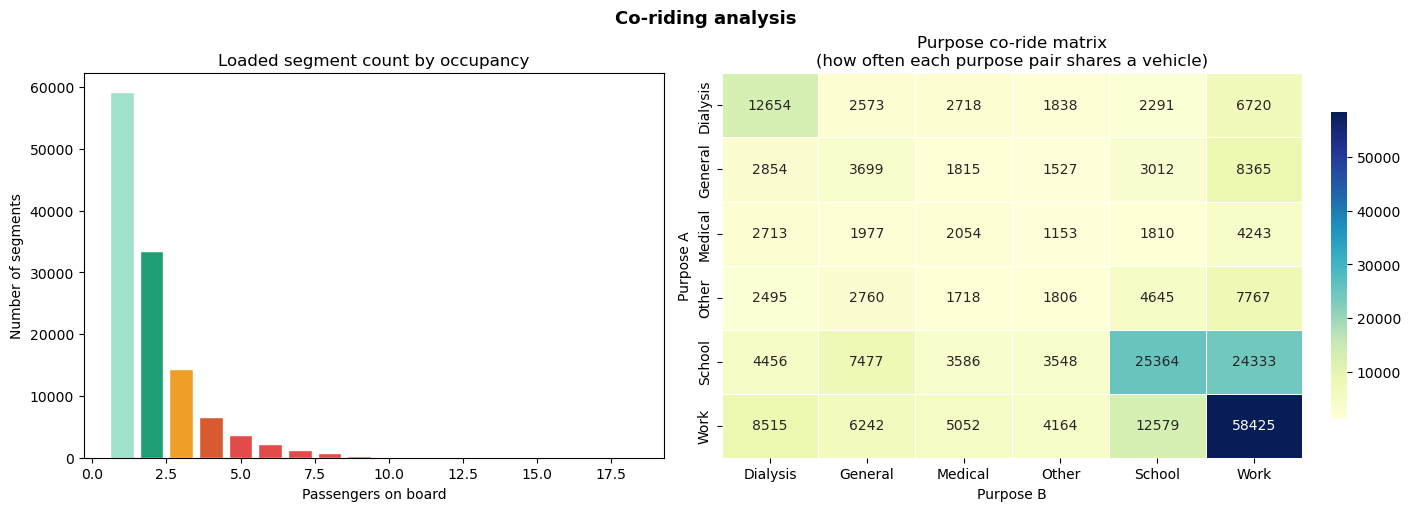

In [9]:
# ── For every loaded segment with ≥2 passengers, record all co-rider pairs
from itertools import combinations

co_ride_pairs = []
for _, seg in segs_df[segs_df['occupancy'] >= 2].iterrows():
    pax  = [p for p in str(seg['passengers_on_board']).split('|') if p]
    purs = [p for p in str(seg['purposes_on_board']).split('|')   if p]
    pax_pur = dict(zip(pax, purs))

    for a, b in combinations(sorted(pax), 2):
        co_ride_pairs.append({
            'vehicle':    seg['vehicle'],
            'trip_date':  seg['trip_date'],
            'rider_a':    a,
            'rider_b':    b,
            'purpose_a':  pax_pur.get(a,''),
            'purpose_b':  pax_pur.get(b,''),
            'shared_dist_mi': seg['distance_mi'],
        })

corides = pd.DataFrame(co_ride_pairs)

if len(corides) > 0:
    # Most frequent co-ride combinations
    coride_freq = (
        corides.groupby(['rider_a','rider_b'])
        .agg(n_times=('vehicle','count'),
             total_shared_mi=('shared_dist_mi','sum'))
        .reset_index()
        .sort_values('n_times', ascending=False)
    )

    # Purpose cross-ride matrix
    coride_purp = pd.crosstab(corides['purpose_a'], corides['purpose_b'])

    corides.to_csv('coride_pairs.csv', index=False)
    print(f'✓ Saved: coride_pairs.csv  ({len(corides):,} co-ride pair-segments)')

    print('\n── Top 10 most frequent co-riding pairs ────────────────')
    display(coride_freq.head(10))

    print('\n── Purpose cross-ride matrix (how often purposes share a vehicle) ─')
    display(coride_purp)

    # Visualize
    import matplotlib.pyplot as plt
    import seaborn as sns
    fig_c, axes_c = plt.subplots(1, 2, figsize=(14, 5),
                                   constrained_layout=True)
    fig_c.suptitle('Co-riding analysis', fontsize=13, fontweight='bold')

    ax = axes_c[0]
    rides_per_occ = segs_df[segs_df['seg_type']=='loaded'].groupby('occupancy').size()
    ax.bar(rides_per_occ.index, rides_per_occ.values,
           color=[occ_color(k) for k in rides_per_occ.index], edgecolor='white')
    ax.set_title('Loaded segment count by occupancy')
    ax.set_xlabel('Passengers on board'); ax.set_ylabel('Number of segments')

    ax = axes_c[1]
    if not coride_purp.empty:
        sns.heatmap(coride_purp, ax=ax, cmap='YlGnBu', annot=True, fmt='d',
                    linewidths=0.5, cbar_kws={'shrink':0.8})
        ax.set_title('Purpose co-ride matrix\n(how often each purpose pair shares a vehicle)')
        ax.set_xlabel('Purpose B'); ax.set_ylabel('Purpose A')

    plt.savefig('coride_analysis.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    print('No co-riding segments found — check that occupancy > 1 segments exist')

## 8. Fleet Utilisation Dashboard

In [10]:
fig = make_subplots(rows=2, cols=3, subplot_titles=[
    'Occupancy distribution (all segments)',
    'Mean occupancy per vehicle',
    'Deadhead % per vehicle',
    'Daily fleet utilisation',
    'Shared vs solo trip distance',
    'Occupancy by hour of day',
])

# 1. Occupancy histogram
occ_hist = segs_df[segs_df['seg_type']=='loaded']['occupancy'].value_counts().sort_index()
fig.add_trace(go.Bar(
    x=occ_hist.index, y=occ_hist.values,
    marker_color=[occ_color(k) for k in occ_hist.index], showlegend=False
), row=1, col=1)

# 2. Mean occupancy per vehicle
veh_occ = (segs_df[segs_df['seg_type']=='loaded']
            .groupby('vehicle')['occupancy'].mean()
            .sort_values(ascending=False)
            .head(30))
fig.add_trace(go.Bar(
    x=veh_occ.values, y=veh_occ.index,
    orientation='h', marker_color='#1D9E75', showlegend=False
), row=1, col=2)

# 3. Deadhead % per vehicle
dh_pct = vday.groupby('vehicle')['deadhead_pct'].mean().sort_values(ascending=False).head(30)
fig.add_trace(go.Bar(
    x=dh_pct.values, y=dh_pct.index,
    orientation='h', marker_color='#E24B4A', showlegend=False
), row=1, col=3)

# 4. Daily active vehicles
daily_veh = segs_df.groupby('trip_date')['vehicle'].nunique().reset_index()
daily_veh.columns = ['Date','Vehicles']
fig.add_trace(go.Scatter(
    x=daily_veh['Date'], y=daily_veh['Vehicles'],
    mode='lines+markers', line_color='#7F77DD',
    fill='tozeroy', fillcolor='rgba(127,119,221,0.12)', showlegend=False
), row=2, col=1)

# 5. Distance: solo (occ=1) vs shared (occ≥2)
solo_dist  = segs_df[segs_df['occupancy']==1]['distance_mi'].sum()
multi_dist = segs_df[segs_df['occupancy']>=2]['distance_mi'].sum()
dh_dist    = segs_df[segs_df['occupancy']==0]['distance_mi'].sum()
fig.add_trace(go.Pie(
    labels=['Solo ride (1 pax)','Shared ride (≥2 pax)','Deadhead (empty)'],
    values=[solo_dist, multi_dist, dh_dist],
    hole=0.4,
    marker_colors=['#378ADD','#1D9E75','#D3D1C7'], showlegend=True
), row=2, col=2)

# 6. Occupancy by hour
segs_df['hour'] = pd.to_datetime(
    segs_df['seg_start_time'], format='%H:%M:%S', errors='coerce'
).dt.hour
hourly_occ = (segs_df[segs_df['seg_type']=='loaded']
               .groupby('hour')['occupancy'].mean().reset_index())
hourly_occ = hourly_occ[(hourly_occ['hour']>=5) & (hourly_occ['hour']<=21)]
fig.add_trace(go.Scatter(
    x=hourly_occ['hour'], y=hourly_occ['occupancy'],
    mode='lines+markers', line_color='#EF9F27',
    fill='tozeroy', fillcolor='rgba(239,159,39,0.12)', showlegend=False
), row=2, col=3)

fig.update_layout(
    height=700, title_text='Fleet Utilisation Dashboard',
    plot_bgcolor='#f8f8f6', paper_bgcolor='white', font_family='Arial'
)
fig.write_html('fleet_dashboard.html')
print('✓ Saved: fleet_dashboard.html')
fig.show()

ValueError: Trace type 'pie' is not compatible with subplot type 'xy'
at grid position (2, 2)

See the docstring for the specs argument to plotly.subplots.make_subplots
for more information on subplot types

## 9. Summary Numbers

In [ ]:
loaded = segs_df[segs_df['seg_type']=='loaded']
dead   = segs_df[segs_df['seg_type']=='deadhead']

print('=' * 60)
print('SHARED-RIDE TOUR RECONSTRUCTION — FLEET SUMMARY')
print('=' * 60)
print(f'Total vehicles           : {segs_df["vehicle"].nunique()}')
print(f'Total tour segments      : {len(segs_df):,}')
print(f'  Loaded segments        : {len(loaded):,}')
print(f'  Deadhead segments      : {len(dead):,}')
print(f'Total loaded distance    : {loaded["distance_mi"].sum():,.1f} mi')
print(f'Total deadhead distance  : {dead["distance_mi"].sum():,.1f} mi')
print(f'Deadhead %               : {dead["distance_mi"].sum() / segs_df["distance_mi"].sum() * 100:.1f}%')
print(f'Mean occupancy (loaded)  : {loaded["occupancy"].mean():.2f} pax')
print(f'Max occupancy seen       : {segs_df["occupancy"].max()}')
print(f'Solo-ride segments       : {(loaded["occupancy"]==1).sum():,}  ({(loaded["occupancy"]==1).mean()*100:.0f}% of loaded)')
print(f'Shared-ride segments     : {(loaded["occupancy"]>=2).sum():,}  ({(loaded["occupancy"]>=2).mean()*100:.0f}% of loaded)')
print(f'Co-ride pairs logged     : {len(corides) if len(corides)>0 else 0:,}')
print(f'\nFiles saved:')
for f in ['vehicle_tour_segments.csv','vehicle_daily_summary.csv',
          'coride_pairs.csv', f'shared_ride_map_{MAP_DATE}.html',
          'occupancy_timeline.html','fleet_dashboard.html','coride_analysis.png']:
    print(f'  {f}')